In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import pickle
from tqdm.auto import tqdm
from glob import glob
import seaborn as sns


In [2]:
os.environ['WORKING_DIR']

'/home/sukaih/Extrastorage/HuaHuaProject/cultural-lexis-finetune-llms'

## READ SWOW English

In [3]:
swow_en_path = os.path.join(os.environ['WORKING_DIR'], 'data/01_raw/SWOW/swow.en.csv')

swow_cn_path = os.path.join(os.environ['WORKING_DIR'], 'data/01_raw/SWOW/SWOWZH.R55.20230424.processed.copy.xlsx')

In [4]:
# en has no header so we need to add it as relation, cue, association and freq
cols = ['relation', 'cue', 'association', 'freq']
swow_en_df = pd.read_csv(swow_en_path, names=cols, sep='\t')

In [5]:
swow_cn_df = pd.read_excel(swow_cn_path)

In [6]:
# general info
swow_en_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384556 entries, 0 to 1384555
Data columns (total 4 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   relation     1384556 non-null  object
 1   cue          1384486 non-null  object
 2   association  1384502 non-null  object
 3   freq         1384556 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 42.3+ MB


In [23]:
swow_en_df.head()

,relation,cue,association,freq
0,forwardassociated,although,nevertheless,3
1,forwardassociated,although,yet,12
2,forwardassociated,although,but,36
3,forwardassociated,although,though,8
4,forwardassociated,although,would,1


In [8]:
# check unique relation types 
swow_en_df['relation'].unique()

array(['forwardassociated'], dtype=object)

In [9]:
# check unique cue types
len(swow_en_df['cue'].unique())

12272

In [10]:
# check unique association types
len(swow_en_df['association'].unique())

122432

/home/sukaih/anaconda3/envs/pftkedro/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


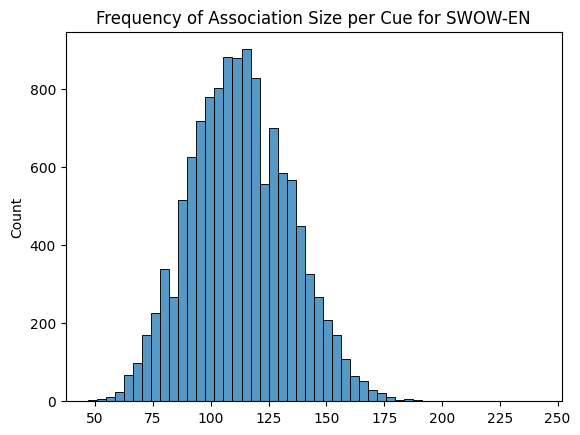

In [11]:
# groupby cue and count association
en_gb_cue_count = swow_en_df.groupby('cue')['association'].count()
frequency = en_gb_cue_count.values
# plot frequency of cue
sns.histplot(frequency, bins=50)
# set title 
plt.title('Frequency of Association Size per Cue for SWOW-EN')
plt.show()

In [12]:
# show the stats of the frequency
en_gb_cue_count.describe()

count    12271.000000
mean       112.821449
std         21.449958
min         47.000000
25%         97.000000
50%        112.000000
75%        127.000000
max        242.000000
Name: association, dtype: float64

In [34]:
# get the max freq group by cue

groupby_cue_freq = swow_en_df.groupby('cue')['freq'].max()
groupby_cue_freq

cue
a           32
aardvark    50
abacus      29
abandon     58
abbey       30
            ..
zombies     27
zone        44
zoo         50
zoom        39
zucchini    52
Name: freq, Length: 12271, dtype: int64

/home/sukaih/anaconda3/envs/pftkedro/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'Max Frequency')

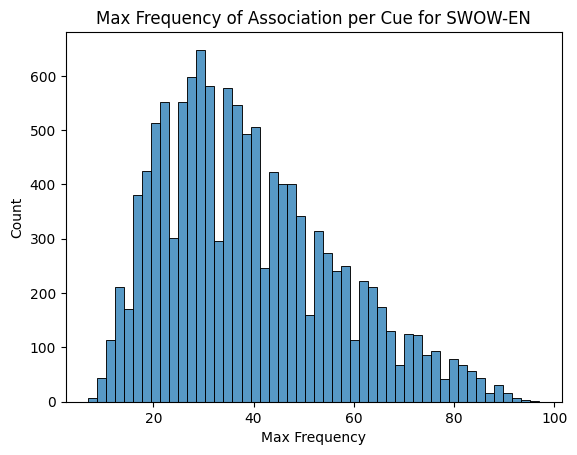

In [35]:

# draw groupby_cue_freq
sns.histplot(groupby_cue_freq, bins=50)
# set title
plt.title('Max Frequency of Association per Cue for SWOW-EN')
# set x label
plt.xlabel('Max Frequency')

In [25]:
swow_en_df_gb_freq = swow_en_df.groupby('cue', group_keys=True)[['association','freq']].apply(lambda x: x)
swow_en_df_gb_freq

association  freq
cue                              
a        28299          one    32
         28300       single     9
         28301        thing     4
         28302            b    14
         28303            c     5
...                     ...   ...
zucchini 662410       shiny     1
         662411    broccoli     1
         662412        thin     1
         662413       fruit     1
         662414         bad     1

[1384486 rows x 2 columns]

In [28]:
swow_en_df.loc[28300]

relation       forwardassociated
cue                            a
association               single
freq                           9
Name: 28300, dtype: object

## Read SWOW ZH

In [13]:
# display general information about the dataset
swow_cn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 809620 entries, 0 to 809619
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   relation     809620 non-null  object
 1   cue          809620 non-null  object
 2   association  809620 non-null  object
 3   freq         809620 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 24.7+ MB


In [14]:
swow_cn_df.head()

,relation,cue,association,freq
0,forwardassociated,T恤,短袖,13
1,forwardassociated,T恤,白色,13
2,forwardassociated,T恤,夏天,12
3,forwardassociated,T恤,衣服,10
4,forwardassociated,T恤,衬衫,10


In [15]:
# check unique relation types
swow_cn_df['relation'].unique()

array(['forwardassociated'], dtype=object)

In [16]:
# check length of unique cues 
len(swow_cn_df['cue'].unique())

10024

In [17]:
# check length of unique association
len(swow_cn_df['association'].unique())

122322

/home/sukaih/anaconda3/envs/pftkedro/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='freq', ylabel='Count'>

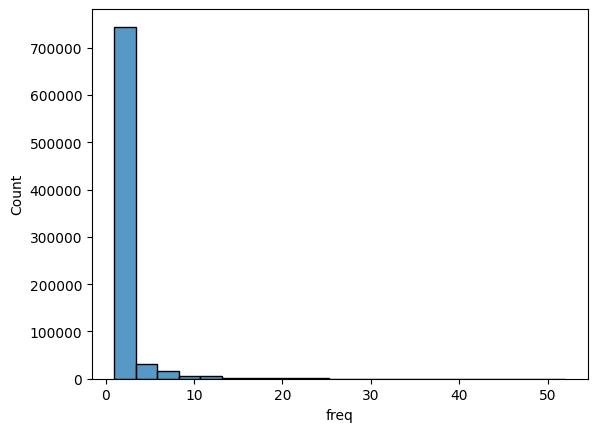

In [18]:
# check the distribution of frequency and draw a histogram

sns.histplot(swow_cn_df['freq'])

/home/sukaih/anaconda3/envs/pftkedro/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


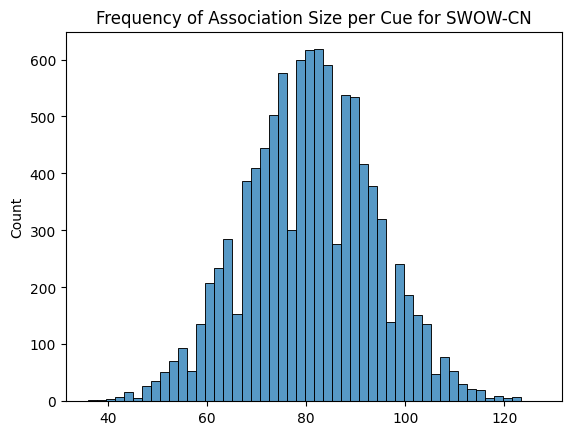

In [19]:
cn_gb_cue_count = swow_cn_df.groupby('cue')['association'].count()
frequency = cn_gb_cue_count.values
# draw a histogram of the frequency of the cues

sns.histplot(frequency, bins=50)
# set the title of the plot
plt.title('Frequency of Association Size per Cue for SWOW-CN')
# show the plot
plt.show()

In [20]:
# show the stats of the frequency
cn_gb_cue_count.describe()

count    10024.000000
mean        80.768156
std         12.988438
min         36.000000
25%         72.000000
50%         81.000000
75%         89.000000
max        127.000000
Name: association, dtype: float64

In [24]:
# get the freq column stats
swow_cn_df['freq'].describe()


count    809620.000000
mean          1.742006
std           2.386177
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          52.000000
Name: freq, dtype: float64

In [30]:
groupby_cue_freq = swow_cn_df.groupby('cue')['freq'].max()
groupby_cue_freq

cue
T恤      13
一       27
一下      17
一丝不苟    21
一个      24
        ..
齿轮      13
龙       13
龙卷风     10
龙虾      11
龟       12
Name: freq, Length: 10024, dtype: int64

/home/sukaih/anaconda3/envs/pftkedro/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 0, 'Max Frequency')

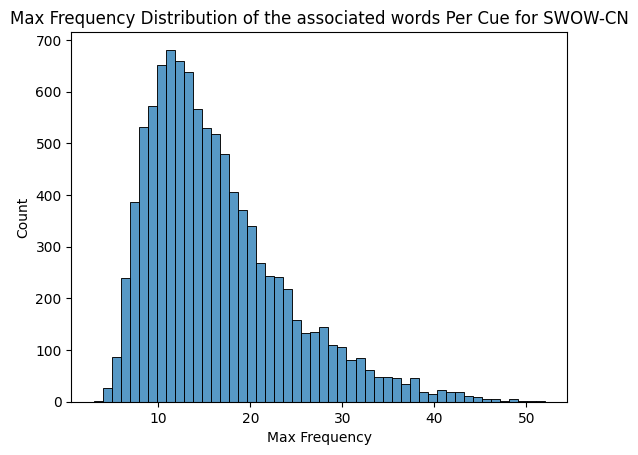

In [33]:
# draw groupby_cue_freq
sns.histplot(groupby_cue_freq, bins=50)
# title 
plt.title('Max Frequency Distribution of the associated words Per Cue for SWOW-CN')
# set x label
plt.xlabel('Max Frequency')